In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quri_parts.qulacs.simulator import evaluate_state_to_vector

def show_distribution(state, n_qubits):
    plt.bar(
        [i for i in range(2**n_qubits)],
        np.abs(evaluate_state_to_vector(state).vector)**2
    )
    plt.xlabel("index")
    plt.ylabel("probability")
    plt.show()

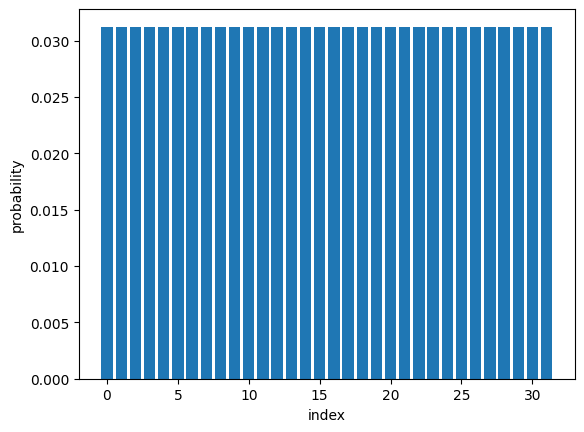

In [3]:
from quri_parts.circuit import QuantumCircuit
from quri_parts.core.state import quantum_state

n_qubits = 5

def make_Hadamard(n_qubits):
    Hadamard = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        Hadamard.add_H_gate(i)
    return Hadamard

Hadamard = make_Hadamard(n_qubits)
state = quantum_state(n_qubits, circuit=Hadamard)
show_distribution(state, n_qubits)

In [4]:
def make_U_w(n_qubits):
    U_w = QuantumCircuit(n_qubits)
    # |1...1>のみを反転させるユニタリ行列ゲート
    U_w.add_UnitaryMatrix_gate(
        list(range(n_qubits)), np.diag([1] * (2**n_qubits - 1) + [-1])
    )
    return U_w

U_w = make_U_w(n_qubits)
state = quantum_state(n_qubits, circuit = Hadamard + U_w)
print(evaluate_state_to_vector(state).vector)

[ 0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j
  0.1767767+0.j  0.1767767+0.j  0.1767767+0.j -0.1767767+0.j]


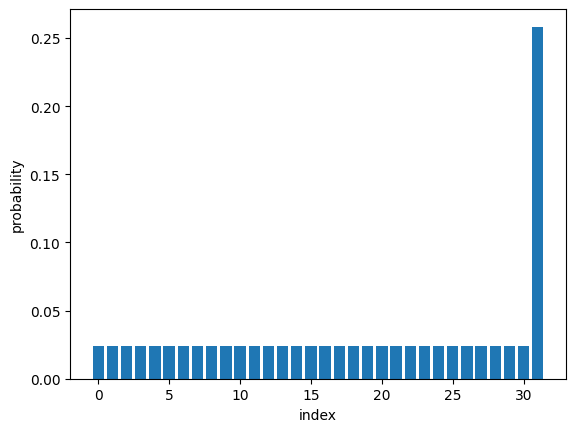

In [5]:
def make_U_s(n_qubits):
    U_s = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        U_s.add_H_gate(i)
    # |0...0>以外に -1 をかけるユニタリ行列ゲート
    U_s.add_UnitaryMatrix_gate(
        list(range(n_qubits)), np.diag([1] + [-1] * (2**n_qubits - 1))
    )
    for i in range(n_qubits):
        U_s.add_H_gate(i)
    return U_s

U_s = make_U_s(n_qubits)
state = quantum_state(n_qubits, circuit = Hadamard + U_w + U_s)
show_distribution(state, n_qubits)

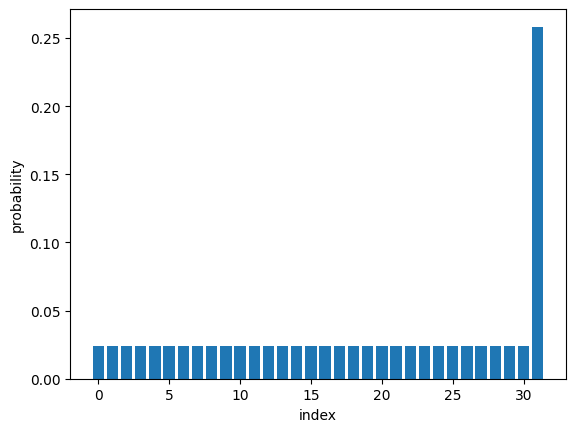

0.25830078124999944


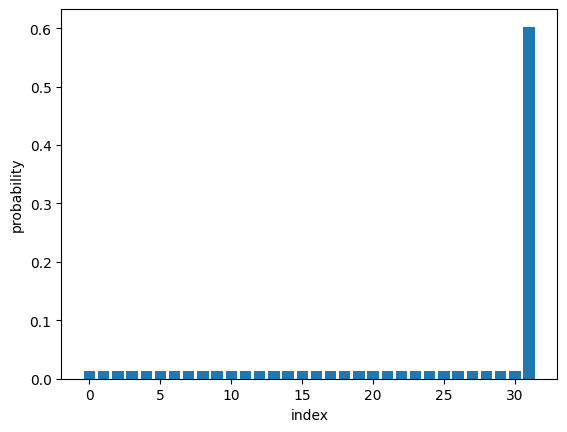

0.6024246215820287


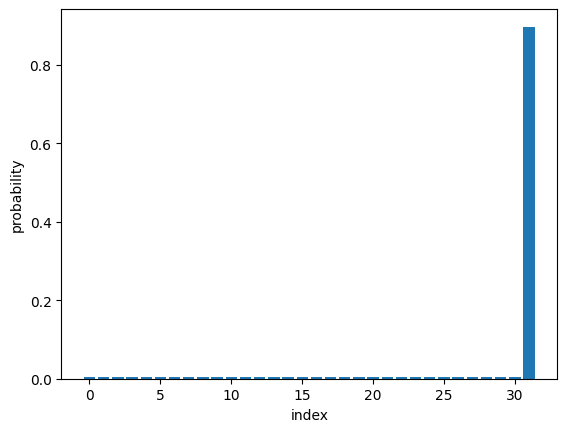

0.8969365358352606


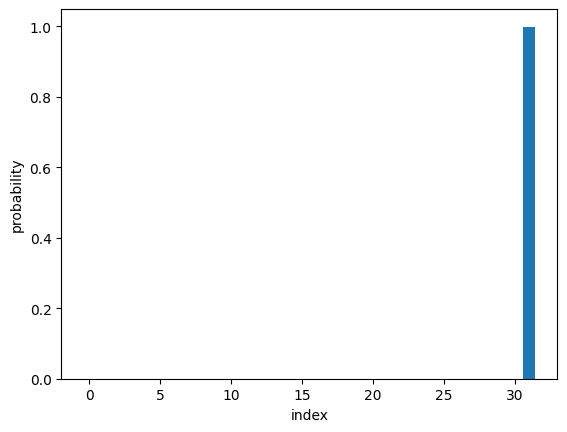

0.9991823155432861


In [6]:
from quri_parts.core.state import apply_circuit
state = quantum_state(n_qubits, circuit=Hadamard)
for k in range(1, 4+1):
    state = apply_circuit(U_w, state)
    state = apply_circuit(U_s, state)
    show_distribution(state, n_qubits)
    print(np.abs(evaluate_state_to_vector(state).vector[-1])**2)

k = 12 で観測確率は最大値9.999470e-01 をとる


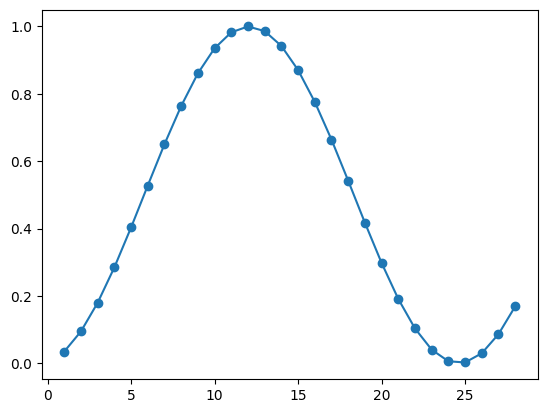

In [7]:
n_qubits = 8
state = quantum_state(n_qubits)

# グローバーのアルゴリズムを実行
Hadamard = make_Hadamard(n_qubits)
Uw = make_U_w(n_qubits)
Us = make_U_s(n_qubits)

result = []

state = quantum_state(n_qubits, circuit=Hadamard)
for k in range(1, 29):
    state = apply_circuit(Uw, state)
    state = apply_circuit(Us, state)
    state_vector = evaluate_state_to_vector(state).vector
    result.append(np.abs(state_vector[-1])**2)

max_k = np.argmax(result)
print( f"k = {max_k + 1} で観測確率は最大値{result[max_k]:5e} をとる")

plt.plot(np.arange(1, 29), result, "o-")
plt.show()

In [8]:
%%time
# ユニタリ行列ゲートの追加が重いので少し時間がかかる
result = []
min_nqubits = 4
max_nqubits = 9
for n_qubits in range(min_nqubits, max_nqubits+1):
    # 回路の準備
    Hadamard = make_Hadamard(n_qubits)
    U_w = make_U_w(n_qubits)
    U_s = make_U_s(n_qubits)

    # 初期状態
    state = quantum_state(n_qubits, circuit=Hadamard)
    # 確率が減少するまでU_s * U_w を繰り返す
    tmp = 0; flag = False; num_iter = 0
    while not flag and num_iter <= 100:
        num_iter += 1
        state = apply_circuit(U_w, state)
        state = apply_circuit(U_s, state)
        state_vector = evaluate_state_to_vector(state).vector
        suc_prob = np.abs(state_vector[-1])**2

        if tmp < suc_prob:
            tmp = suc_prob
        else:
            flag = True
    result.append( [n_qubits, num_iter, suc_prob] )
    print(f"n_qubits={n_qubits}, num_iter={num_iter}, suc_prob={suc_prob:5e}")

n_qubits=4, num_iter=4, suc_prob=5.817041e-01
n_qubits=5, num_iter=5, suc_prob=8.596367e-01
n_qubits=6, num_iter=7, suc_prob=9.074492e-01
n_qubits=7, num_iter=9, suc_prob=9.877786e-01
n_qubits=8, num_iter=13, suc_prob=9.861862e-01
n_qubits=9, num_iter=18, suc_prob=9.957912e-01
CPU times: user 31 s, sys: 1.29 s, total: 32.3 s
Wall time: 36 s


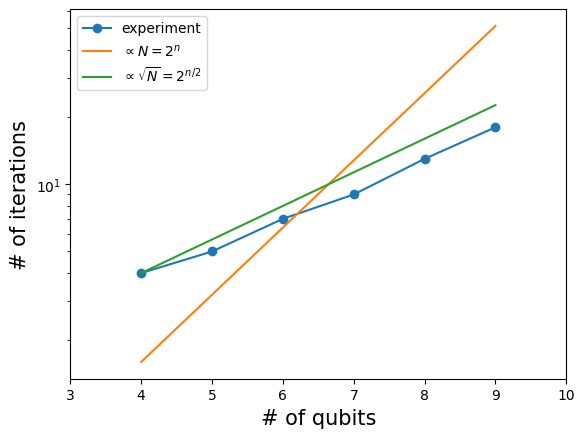

In [9]:
result_array = np.array(result)
plt.xlim(min_nqubits-1, max_nqubits+1)
plt.xlabel("# of qubits", fontsize=15)
plt.ylabel("# of iterations", fontsize=15)
plt.semilogy(result_array[:,0], result_array[:,1], "o-", label="experiment")
plt.semilogy(result_array[:,0], 0.1 * 2**result_array[:,0], "-",
label=r"$\propto N=2^n$")
plt.semilogy(result_array[:,0], 2**(0.5*result_array[:,0]), "-",
label=r"$\propto \sqrt{N}=2^{n/2}$")
plt.legend(fontsize=10)
plt.show()